Loaded 810 realizations with 8 theta bins (use_fkp=True).


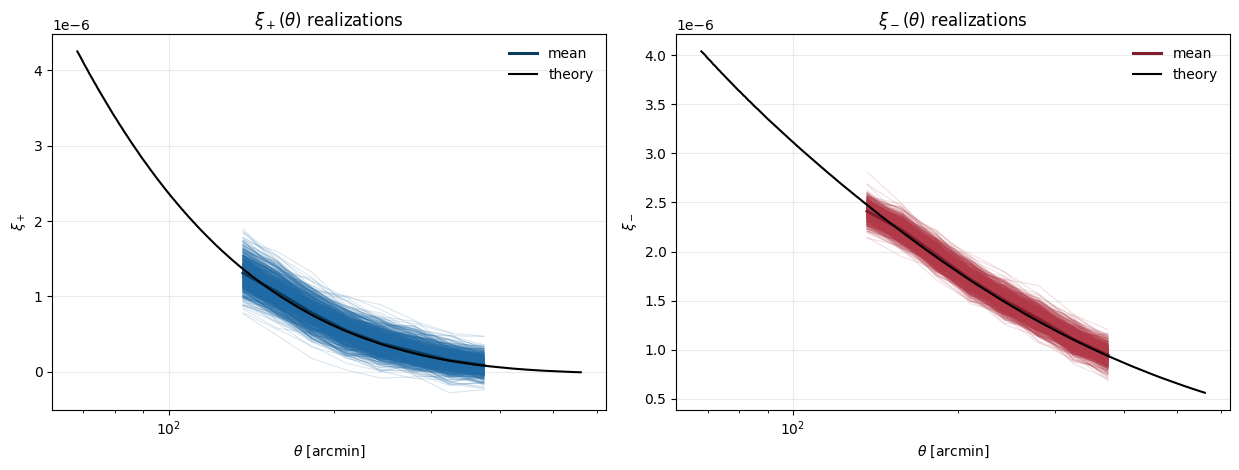

cov_xip shape: (8, 8)
cov_xim shape: (8, 8)
cov_joint shape: (16, 16)
SNR(xi+)           = 7.489
SNR(xi-)           = 34.216
SNR(total joint)   = 35.867
Hartlap factor     = 0.9790
SNR(total, Hartlap)= 35.488


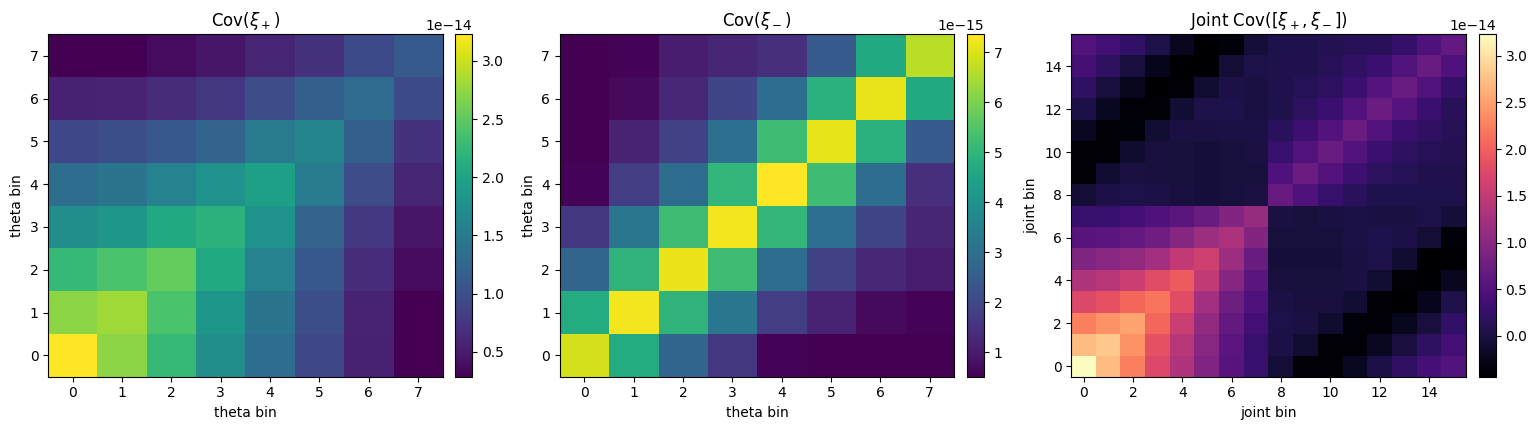

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#npz_path = "./../output/xi_pm_realisations_uniform_crazy.npz"
npz_path = "./../output/xi_pm_realisations_fkp_crazy.npz"
d = np.load(npz_path)

theta = d["theta"]
xip = d["xip"]  # shape: (n_real, n_theta)
xim = d["xim"]  # shape: (n_real, n_theta)
use_fkp = bool(d["use_fkp"])

theta_th = d["theta_th"]   # arcmin, finer grid
xi_p_th  = d["xi_p_th"]
xi_m_th  = d["xi_m_th"]

n_real, n_theta = xip.shape
print(f"Loaded {n_real} realizations with {n_theta} theta bins (use_fkp={use_fkp}).")

# Plot all realizations and the mean curve for xi+ and xi-
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)

for i in range(n_real):
    axes[0].plot(theta, xip[i], color="#1f6aa5", alpha=0.16, lw=0.8)
    axes[1].plot(theta, xim[i], color="#b23a48", alpha=0.16, lw=0.8)

axes[0].plot(theta, xip.mean(axis=0), color="#0b3c5d", lw=2.2, label="mean")
axes[1].plot(theta, xim.mean(axis=0), color="#7f1d2d", lw=2.2, label="mean")

axes[0].plot(theta_th, xi_p_th, "k-", lw=1.5, label="theory")
axes[1].plot(theta_th, xi_m_th, "k-", lw=1.5, label="theory")

axes[0].set_title(r"$\xi_+(\theta)$ realizations")
axes[1].set_title(r"$\xi_-(\theta)$ realizations")
for ax, ylab in zip(axes, [r"$\xi_+$", r"$\xi_-$"]):
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(ylab)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

# Covariance matrices
cov_xip = np.cov(xip, rowvar=False, ddof=1)   # (n_theta, n_theta)
cov_xim = np.cov(xim, rowvar=False, ddof=1)   # (n_theta, n_theta)

# Joint covariance for [xi+, xi-]
xi_joint = np.concatenate([xip, xim], axis=1)  # (n_real, 2*n_theta)
cov_joint = np.cov(xi_joint, rowvar=False, ddof=1)  # (2*n_theta, 2*n_theta)

print("cov_xip shape:", cov_xip.shape)
print("cov_xim shape:", cov_xim.shape)
print("cov_joint shape:", cov_joint.shape)

# Signal-to-noise ratio estimates: SNR^2 = mu^T C^{-1} mu
# Use pseudo-inverse for numerical stability.
mu_xip = xip.mean(axis=0)
mu_xim = xim.mean(axis=0)
mu_joint = np.concatenate([mu_xip, mu_xim])

inv_cov_xip = np.linalg.pinv(cov_xip)
inv_cov_xim = np.linalg.pinv(cov_xim)
inv_cov_joint = np.linalg.pinv(cov_joint)

snr2_xip = float(mu_xip @ inv_cov_xip @ mu_xip)
snr2_xim = float(mu_xim @ inv_cov_xim @ mu_xim)
snr2_joint = float(mu_joint @ inv_cov_joint @ mu_joint)

snr_xip = np.sqrt(max(snr2_xip, 0.0))
snr_xim = np.sqrt(max(snr2_xim, 0.0))
snr_joint = np.sqrt(max(snr2_joint, 0.0))

# Hartlap correction (for inverse covariance bias from finite realizations)
p_joint = 2 * n_theta
hartlap = (n_real - p_joint - 2) / (n_real - 1) if n_real > p_joint + 2 else np.nan
snr_joint_hartlap = np.sqrt(max(hartlap * snr2_joint, 0.0)) if np.isfinite(hartlap) else np.nan

print(f"SNR(xi+)           = {snr_xip:.3f}")
print(f"SNR(xi-)           = {snr_xim:.3f}")
print(f"SNR(total joint)   = {snr_joint:.3f}")
if np.isfinite(hartlap):
    print(f"Hartlap factor     = {hartlap:.4f}")
    print(f"SNR(total, Hartlap)= {snr_joint_hartlap:.3f}")

# Visualize covariance blocks
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

im0 = axes[0].imshow(cov_xip, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title(r"Cov$(\xi_+)$")
axes[0].set_xlabel("theta bin")
axes[0].set_ylabel("theta bin")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(cov_xim, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title(r"Cov$(\xi_-)$")
axes[1].set_xlabel("theta bin")
axes[1].set_ylabel("theta bin")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

im2 = axes[2].imshow(cov_joint, origin="lower", aspect="auto", cmap="magma")
axes[2].set_title(r"Joint Cov$([\xi_+,\xi_-])$")
axes[2].set_xlabel("joint bin")
axes[2].set_ylabel("joint bin")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)

fig.tight_layout()
plt.show()

Jackknife covariance-error summary (median |sigma(C_ii)/C_ii|):
  xi+   : 0.050
  xi-   : 0.049
  joint : 0.050

SNR with propagated covariance-estimation uncertainty (jackknife):
  SNR(xi+)         = 7.489 +/- 0.194
  SNR(xi-)         = 34.216 +/- 0.888
  SNR(total joint) = 35.867 +/- 0.944
  SNR(total, Hartlap) = 35.488 +/- 0.934


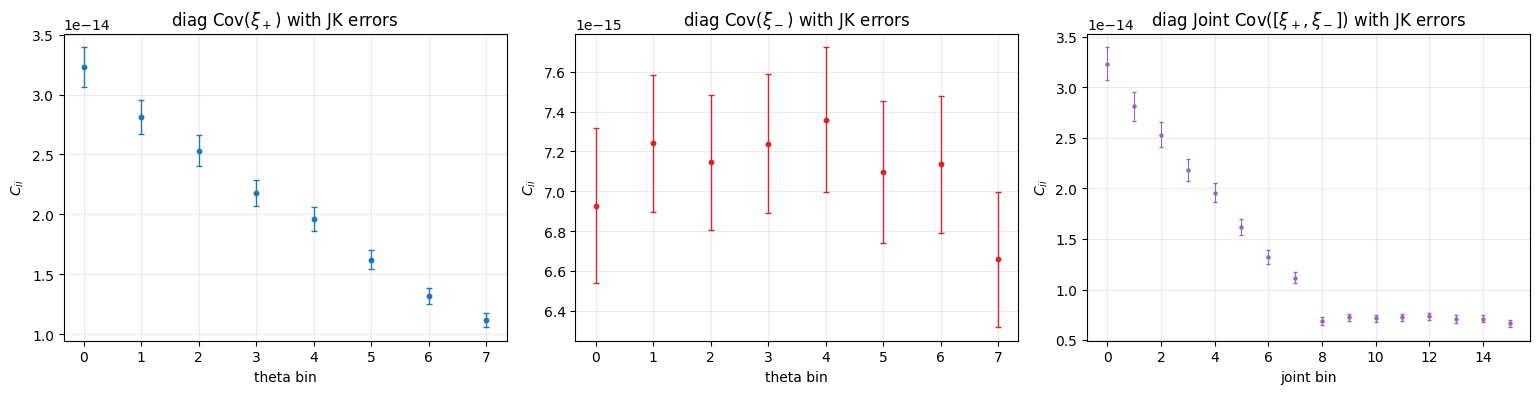

In [24]:
# Jackknife uncertainty estimate for covariance matrices (leave-one-realisation-out).
def jackknife_covariance_se(samples, ddof=1):
    samples = np.asarray(samples, dtype=float)
    if samples.ndim != 2:
        raise ValueError("samples must be a 2D array: (n_real, n_features)")

    n_real_local, n_feat = samples.shape
    if n_real_local < 4:
        raise ValueError("Need at least 4 realizations for stable jackknife covariance errors")

    jk_cov = np.empty((n_real_local, n_feat, n_feat), dtype=float)
    for i in range(n_real_local):
        keep = np.ones(n_real_local, dtype=bool)
        keep[i] = False
        jk_cov[i] = np.cov(samples[keep], rowvar=False, ddof=ddof)

    jk_mean = jk_cov.mean(axis=0)
    # Jackknife variance formula for an estimator built from leave-one-out replicates.
    jk_var = (n_real_local - 1.0) / n_real_local * np.sum((jk_cov - jk_mean) ** 2, axis=0)
    jk_se = np.sqrt(np.clip(jk_var, 0.0, None))
    return jk_mean, jk_se

def jackknife_stat_se(stat_values):
    stat_values = np.asarray(stat_values, dtype=float)
    n = stat_values.size
    if n < 2:
        return np.nan
    stat_mean = np.mean(stat_values)
    stat_var = (n - 1.0) / n * np.sum((stat_values - stat_mean) ** 2)
    return float(np.sqrt(max(stat_var, 0.0)))

def snr_from_cov(mu, cov):
    snr2_val = float(mu @ np.linalg.pinv(cov) @ mu)
    return float(np.sqrt(max(snr2_val, 0.0)))

def jackknife_snr_error_from_cov(samples, mu, ddof=1, apply_hartlap=False):
    samples = np.asarray(samples, dtype=float)
    mu = np.asarray(mu, dtype=float)
    n_real_local, p_dim = samples.shape
    snr_rep = np.empty(n_real_local, dtype=float)

    for i in range(n_real_local):
        keep = np.ones(n_real_local, dtype=bool)
        keep[i] = False
        cov_i = np.cov(samples[keep], rowvar=False, ddof=ddof)
        snr2_i = float(mu @ np.linalg.pinv(cov_i) @ mu)

        if apply_hartlap:
            n_eff = n_real_local - 1
            if n_eff > p_dim + 2:
                hartlap_i = (n_eff - p_dim - 2) / (n_eff - 1)
                snr2_i = hartlap_i * snr2_i
            else:
                snr2_i = np.nan

        snr_rep[i] = np.sqrt(max(snr2_i, 0.0)) if np.isfinite(snr2_i) else np.nan

    valid = np.isfinite(snr_rep)
    if not np.any(valid):
        return np.nan, snr_rep
    return jackknife_stat_se(snr_rep[valid]), snr_rep

# Compute jackknife standard errors for covariance elements.
_, cov_xip_se_jk = jackknife_covariance_se(xip, ddof=1)
_, cov_xim_se_jk = jackknife_covariance_se(xim, ddof=1)
_, cov_joint_se_jk = jackknife_covariance_se(xi_joint, ddof=1)

diag_xip = np.diag(cov_xip)
diag_xim = np.diag(cov_xim)
diag_joint = np.diag(cov_joint)
diag_xip_se = np.diag(cov_xip_se_jk)
diag_xim_se = np.diag(cov_xim_se_jk)
diag_joint_se = np.diag(cov_joint_se_jk)

def median_frac_err(diag_val, diag_err):
    m = np.abs(diag_val) > 0
    return np.median(np.abs(diag_err[m] / diag_val[m])) if np.any(m) else np.nan

print("Jackknife covariance-error summary (median |sigma(C_ii)/C_ii|):")
print(f"  xi+   : {median_frac_err(diag_xip, diag_xip_se):.3f}")
print(f"  xi-   : {median_frac_err(diag_xim, diag_xim_se):.3f}")
print(f"  joint : {median_frac_err(diag_joint, diag_joint_se):.3f}")

# Propagate covariance-estimation error into SNR via jackknife of the covariance estimator.
snr_xip_jk_err, _ = jackknife_snr_error_from_cov(xip, mu_xip, ddof=1, apply_hartlap=False)
snr_xim_jk_err, _ = jackknife_snr_error_from_cov(xim, mu_xim, ddof=1, apply_hartlap=False)
snr_joint_jk_err, _ = jackknife_snr_error_from_cov(xi_joint, mu_joint, ddof=1, apply_hartlap=False)
snr_joint_hartlap_jk_err, _ = jackknife_snr_error_from_cov(xi_joint, mu_joint, ddof=1, apply_hartlap=True)

print("\nSNR with propagated covariance-estimation uncertainty (jackknife):")
print(f"  SNR(xi+)         = {snr_xip:.3f} +/- {snr_xip_jk_err:.3f}")
print(f"  SNR(xi-)         = {snr_xim:.3f} +/- {snr_xim_jk_err:.3f}")
print(f"  SNR(total joint) = {snr_joint:.3f} +/- {snr_joint_jk_err:.3f}")
if np.isfinite(snr_joint_hartlap):
    print(f"  SNR(total, Hartlap) = {snr_joint_hartlap:.3f} +/- {snr_joint_hartlap_jk_err:.3f}")

# Optional diagnostic plot: covariance diagonal with jackknife 1-sigma errors.
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2), sharex=False)
i_xip = np.arange(diag_xip.size)
i_xim = np.arange(diag_xim.size)
i_joint = np.arange(diag_joint.size)

axes[0].errorbar(i_xip, diag_xip, yerr=diag_xip_se, fmt="o", ms=3.2, lw=1.0, capsize=2.0, color="tab:blue")
axes[0].set_title(r"diag Cov$(\xi_+)$ with JK errors")
axes[0].set_xlabel("theta bin")
axes[0].set_ylabel(r"$C_{ii}$")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(i_xim, diag_xim, yerr=diag_xim_se, fmt="o", ms=3.2, lw=1.0, capsize=2.0, color="tab:red")
axes[1].set_title(r"diag Cov$(\xi_-)$ with JK errors")
axes[1].set_xlabel("theta bin")
axes[1].set_ylabel(r"$C_{ii}$")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(i_joint, diag_joint, yerr=diag_joint_se, fmt="o", ms=2.2, lw=0.8, capsize=1.5, color="tab:purple")
axes[2].set_title(r"diag Joint Cov$([\xi_+,\xi_-])$ with JK errors")
axes[2].set_xlabel("joint bin")
axes[2].set_ylabel(r"$C_{ii}$")
axes[2].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()